In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import time
import random
import IPython
from scipy.integrate import solve_ivp
import networkx as nx
from  networkx.algorithms.approximation import min_weighted_dominating_set as dominating_set
import seaborn as sns

class EpidemicSimulator:
    def __init__(self, G):
        self.G = G
        self.A = nx.to_numpy_array(G)
        self.n = len(G)

    def _ode_system(self, t, y, gamma_nodes, W_beta, W_epsilon):
        S = y[0 : self.n]
        I = y[self.n : 2 * self.n]
        R = y[2 * self.n : 3 * self.n]

        # Force d'infection locale
        Lambda = I @ W_beta
        Omega = I @ W_epsilon

        dSdt = - S * Lambda
        dIdt = S * Lambda - gamma_nodes * I + R * Omega
        dRdt = gamma_nodes * I - R * Omega

        return np.concatenate([dSdt, dIdt, dRdt])

    def run_siri_v(self, m, vaccinated, params, initials, mode="SIRI"):
        vac = np.array(vaccinated)

        beta_nodes = np.where(vac, params['b'], params['beta'])
        eps_nodes = np.where(vac, params['e'], params['epsilon'])
        gamma_nodes = np.where(vac, params['g'], params['gamma'])
        h_neighbor = params['h']

        # Matrices de poids effectives j -> i
        B = np.where(vac[:, None], h_neighbor, beta_nodes[None, :])
        E = np.where(vac[:, None], h_neighbor, eps_nodes[None, :])

        W_beta = self.A * B
        W_epsilon = self.A * E

        if mode == "SI":
            gamma_nodes = np.zeros(self.n)
            W_epsilon = np.zeros((self.n, self.n))

        y0 = np.concatenate([initials['S'], initials['I'], initials['R']])
        t_span = (0, m - 1)
        t_eval = np.arange(m)

        sol = solve_ivp(
            self._ode_system,
            t_span,
            y0,
            t_eval=t_eval,
            args=(gamma_nodes, W_beta, W_epsilon),
            method='RK45'
        )

        S_hist = sol.y[0 : self.n, :]
        I_hist = sol.y[self.n : 2 * self.n, :]
        R_hist = sol.y[2 * self.n : 3 * self.n, :]

        # On retourne les détails nodaux nécessaires pour l'évaluation des métriques
        return S_hist, I_hist, R_hist, W_epsilon, vac


class EpidemicEvaluator:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def compute_metrics(self, S_hist, I_hist, R_hist, W_epsilon, vac, vc, baseline_attack_rate=None):
        metrics = {}

        # Population totale par compartiment à chaque instant
        S_total = np.sum(S_hist, axis=0)
        I_total = np.sum(I_hist, axis=0)
        R_total = np.sum(R_hist, axis=0)

        # 1. Temporal Dynamics (Curve Analysis)
        metrics['I_max'] = np.max(I_total)  # Pic de prévalence
        metrics['T_peak'] = np.argmax(I_total)  # Temps du pic
        metrics['Attack_Rate'] = 1.0 - (S_total[-1] / self.n)  # Taille finale de l'épidémie

        # 2. Network Connectivity & Robustness
        # On considère les nœuds vaccinés comme "retirés" topologiquement si leur immunité est forte
        unvaccinated_nodes = [u for u in self.G.nodes() if not vac[u]]
        if len(unvaccinated_nodes) > 0:
            G_rem = self.G.subgraph(unvaccinated_nodes)
            # Taille de la plus grande composante connexe restante
            metrics['Giant_Component'] = max(len(c) for c in nx.connected_components(G_rem))
            # Connectivité algébrique (deuxième plus petite valeur propre du Laplacien)
            try:
                metrics['Algebraic_Connectivity'] = nx.algebraic_connectivity(G_rem)
            except:
                metrics['Algebraic_Connectivity'] = 0.0
        else:
            metrics['Giant_Component'] = 0
            metrics['Algebraic_Connectivity'] = 0.0

        # Degré effectif moyen (on ne compte que les liens vers des voisins non-vaccinés)
        eff_degrees = [sum(1 for nbr in self.G.neighbors(node) if not vac[nbr]) for node in self.G.nodes()]
        metrics['Mean_Effective_Degree'] = np.mean(eff_degrees)

        # 3. Strategy Efficiency Metrics
        if baseline_attack_rate is not None and vc > 0:
            metrics['Vaccine_Efficiency'] = (baseline_attack_rate - metrics['Attack_Rate']) / vc
        else:
            metrics['Vaccine_Efficiency'] = 0.0

        # 4. SIRI Specific: Re-infection & Persistence
        # Persistance : le virus reste-t-il endémique en fin de simulation ? (seuil à 0.5% de la pop)
        metrics['Persistence'] = 1 if (I_total[-1] / self.n) > 0.005 else 0

        # Taux de réinfection cumulé : Somme sur t de (R_i(t) * Omega_i(t))
        total_reinfections = 0.0
        for t in range(I_hist.shape[1]):
            I_t = I_hist[:, t]
            R_t = R_hist[:, t]
            Omega_t = I_t @ W_epsilon  # Force de réinfection subie à l'instant t
            total_reinfections += np.sum(R_t * Omega_t)

        metrics['Total_Reinfections'] = total_reinfections

        return metrics


# --- CLASSES DE STRATÉGIE DE VACCINATION ---
class VaccinationStrategy:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def _fill_remaining_vaccinations(self, vaccinated, ids, nI):
        """Helper pour compléter aléatoirement la vaccination si le DS est trop petit"""
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
            remaining = list(set(range(self.n)) - set(ids))
            random.shuffle(remaining)
            for idx in remaining[:nI - len(ids)]:
                vaccinated[idx] = True
        return vaccinated

class NoVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        return [False] * self.n

class DegreeVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        degrees = [self.G.degree(node) for node in ids]
        ids = [x for _, x in sorted(zip(degrees, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class DegreeCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.degree_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class BetweennessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.betweenness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class ClosenessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.closeness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class EigenVectorCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.eigenvector_centrality(self.G, max_iter=1000)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class RandomVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        if dominating_set_ is None:
            ids = list(range(self.n))
        else:
            ids = list(dominating_set_)
        random.shuffle(ids)
        for idx in ids[:nI]:
            vaccinated[idx] = True
        return vaccinated

class VaccinationStrategyFactory:
    def __init__(self, G):
        self.G = G
    def get_strategy(self, strategy_name):
        if strategy_name == "no_vac":
            return NoVaccinationStrategy(self.G)
        elif strategy_name == "degree":
            return DegreeVaccinationStrategy(self.G)
        elif strategy_name == "degree_centrality":
            return DegreeCentralityVaccinationStrategy(self.G) # Corrigé (NameError original)
        elif strategy_name == "betweenness_centrality":
            return BetweennessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "closeness_centrality":
            return ClosenessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "eigenvector_centrality":
            return EigenVectorCentralityVaccinationStrategy(self.G)
        elif strategy_name == "random":
            return RandomVaccinationStrategy(self.G)
        else:
            raise ValueError("Invalid vaccination strategy")

# --- PIPELINE GLOBAL D'ÉVALUATION ---

class EpidemicSimulationPipeline:
    def __init__(self, G):
        self.G = G
        self.simulator = EpidemicSimulator(G)
        self.evaluator = EpidemicEvaluator(G)
        self.factory = VaccinationStrategyFactory(G)

    def run_comparison(self, strategies, m, params, initials, vc=0.1, use_ds=True):
        results = {}
        baseline_attack_rate = None

        # Étape 1 : On commence toujours par exécuter "no_vac" pour avoir la référence (Baseline)
        if "no_vac" in strategies:
            strat = self.factory.get_strategy("no_vac")
            vac = strat.select_vaccinated([], 0.0)
            S, I, R, W_eps, v_arr = self.simulator.run_siri_v(m, vac, params, initials, "SIRI")
            res_no_vac = self.evaluator.compute_metrics(S, I, R, W_eps, v_arr, vc=0.0)
            baseline_attack_rate = res_no_vac['Attack_Rate']
            results['no_vac'] = res_no_vac

        # Étape 2 : Évaluation des autres stratégies de vaccination
        dom_set = dominating_set(self.G,weight=None) if use_ds else list(self.G.nodes())

        for name in strategies:
            if name == "no_vac": continue

            strat = self.factory.get_strategy(name)
            vac = strat.select_vaccinated(dom_set, vc)
            S, I, R, W_eps, v_arr = self.simulator.run_siri_v(m, vac, params, initials, "SIRI")

            results[name] = self.evaluator.compute_metrics(
                S, I, R, W_eps, v_arr, vc, baseline_attack_rate
            )

        # Mise en forme dans un DataFrame Pandas propre
        df = pd.DataFrame(results).T
        return df

In [5]:
def plot_comparison_bar_charts(df_ds, df_nds, metrics=None, figsize=(20, 18), palette='viridis'):
    if metrics is None:
        metrics = [
            'I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',
            'Algebraic_Connectivity', 'Total_Reinfections',
            'Mean_Effective_Degree', 'Vaccine_Efficiency', 'Persistence'
        ]

    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Prepare data for plotting
        plot_data = pd.DataFrame({
            'Strategy': df_ds.index.tolist() + df_nds.index.tolist(),
            'Value': df_ds[metric].tolist() + df_nds[metric].tolist(),
            'Scenario': ['Dominating Set'] * len(df_ds) + ['No Dominating Set'] * len(df_nds)
        })

        # Plot side-by-side bar plots using seaborn
        sns.barplot(data=plot_data, x='Strategy', y='Value', hue='Scenario', ax=ax, palette=palette)
        ax.set_title(f'Comparison of {metric}')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')

    plt.tight_layout()
    plt.show()


In [8]:
!unzip Net\ data\ 2026.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
G=nx.read_weighted_edgelist('Dublin.txt')
A=nx.to_numpy_array(G)
G=nx.from_numpy_array(A)
n = len(G)

In [10]:
def run_epidemic_simulation_comparison(G, n, params, initials, vc, m=50, strategies=None, use_ds=True):
    if strategies is None:
        strategies = ["no_vac", "random", "degree", "degree_centrality", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

    pipeline = EpidemicSimulationPipeline(G)

    df_comparatif = pipeline.run_comparison(
        strategies=strategies,
        m=m,
        params=params,
        initials=initials,
        vc=vc,
        use_ds=use_ds
    )
    return df_comparatif

init_I = np.zeros(n)
init_I[random.sample(range(n), int(n * 0.01))] = 1.0
init_S = 1.0 - init_I
init_R = np.zeros(n)

initials = {'S': init_S, 'I': init_I, 'R': init_R}



## SIRI MODEL

In [11]:
params = {
    'beta': 0.08,    # On baisse fortement la transmission (le virus se propage moins vite)
    'epsilon': 0.02, # Faible taux de réinfection naturelle
    'gamma': 0.1,    # On augmente la vitesse de guérison (durée moyenne d'infection = 10 jours)

    # On rend le vaccin beaucoup plus "stérilisant" (immunité forte)
    'b': 0.005,      # Transmission presque nulle chez le vacciné
    'e': 0.001,      # Réinfection presque impossible chez le vacciné
    'g': 0.15,       # Le vacciné guérit encore plus vite
    'h': 0.001       # Un vacciné infecté ne contamine presque personne
}


### using dominating set

In [12]:

# 4. Exécution du pipeline
# liste_strategies = ["no_vac", "random", "degree", "degree_centrality", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Couverture vaccinale (15%)
    m=50,
    use_ds=True
)

# Affichage du tableau de bord d'analyse
print(df_comparatif[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  276.536926     0.995850    10.0            410.0   
random                  139.716606     0.781118    17.0            247.0   
degree                  108.143792     0.661374    32.0            246.0   
degree_centrality       108.143792     0.661374    32.0            246.0   
betweenness_centrality  100.143826     0.699853    28.0            181.0   
closeness_centrality    113.853021     0.645011    21.0            125.0   
eigenvector_centrality  123.847548     0.587965    15.0            154.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462          974.859725  
random                                0.000000          337.713579  
degree                                0.000000          134.033211  
degree_centrality                     0.000000          134.033211  
betweenness_centrality                0.000000

### withouth using the dominating set

In [14]:
df_comparatif = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Couverture vaccinale (15%)
    m=50,
    use_ds=False
)

# Affichage du tableau de bord d'analyse
print(df_comparatif[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  276.536926     0.995850    10.0            410.0   
random                  166.178372     0.834162    13.0            261.0   
degree                  110.982718     0.670886    31.0            247.0   
degree_centrality       110.982718     0.670886    31.0            247.0   
betweenness_centrality  106.749247     0.697625    23.0            179.0   
closeness_centrality    131.102633     0.695975    19.0            136.0   
eigenvector_centrality  148.445471     0.633908    13.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462          974.859725  
random                                0.000000          463.802789  
degree                                0.000000          162.286162  
degree_centrality                     0.000000          162.286162  
betweenness_centrality                0.000000

### Plots

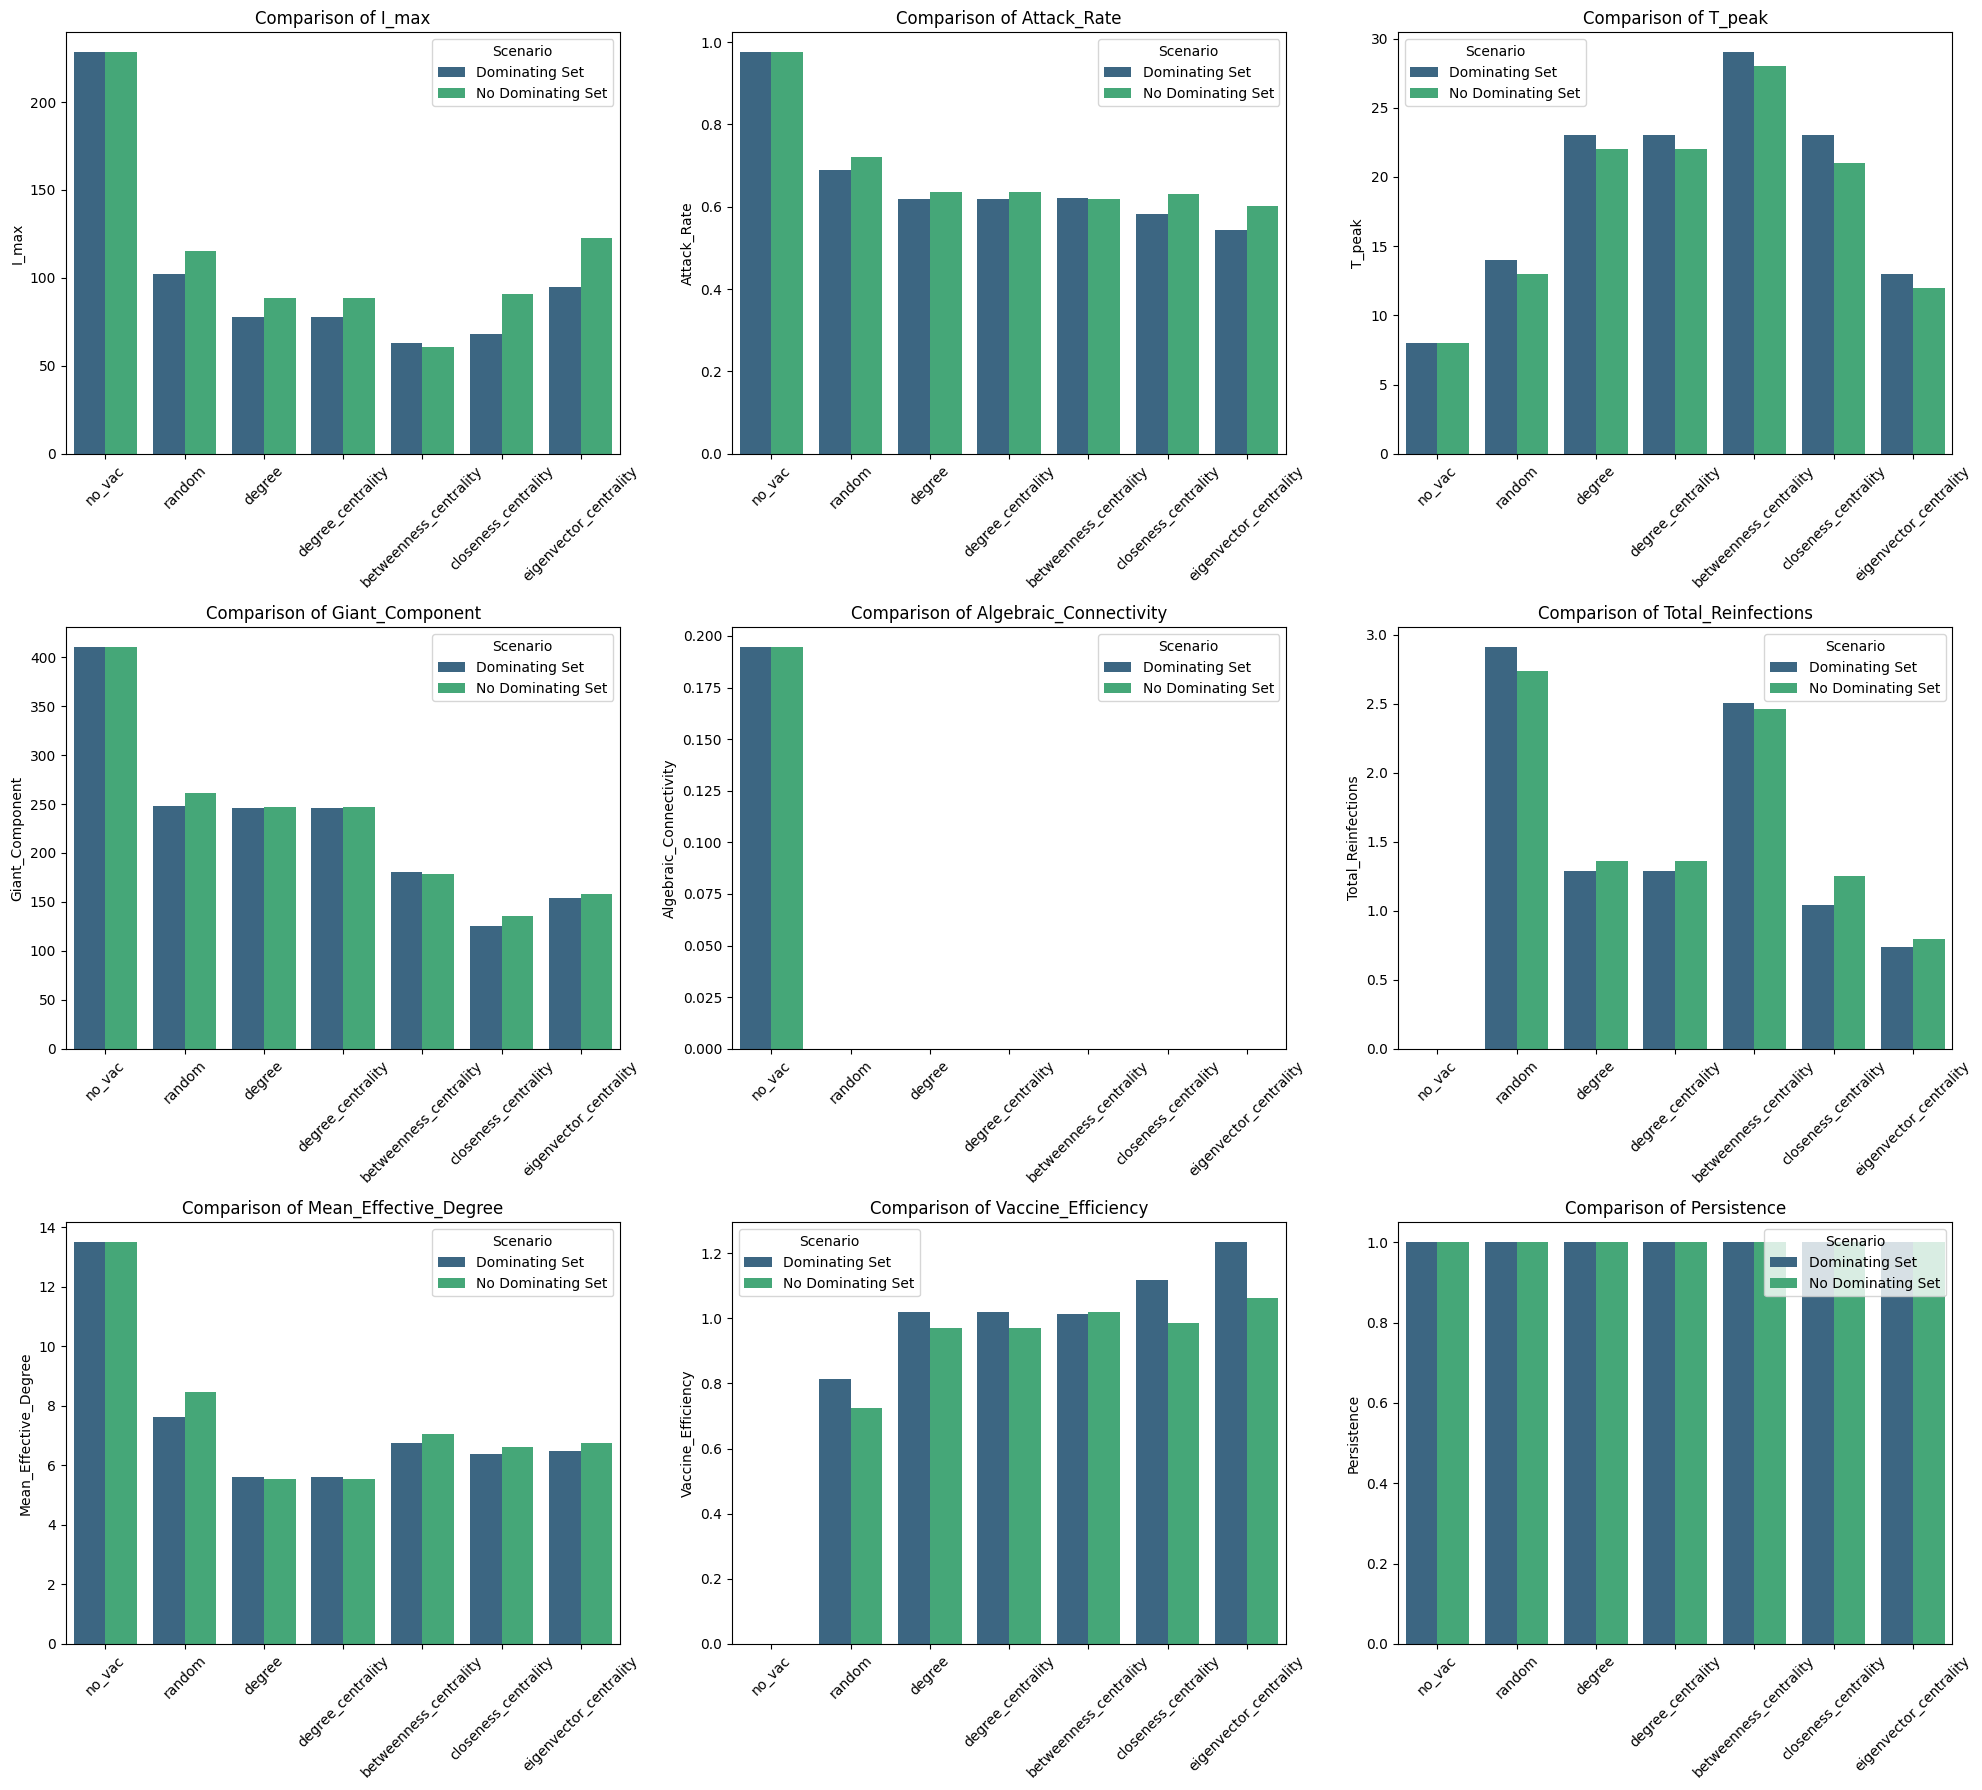

In [ ]:
plot_comparison_bar_charts(df_comparatif_ds, df_comparatif_nds)

## SIR MODEL

In [ ]:
params = {
    'beta': 0.08,    # Taux de transmission standard (S -> I)
    'gamma': 0.1,    # Taux de guérison standard (I -> R)

    # --- AJUSTEMENT SIR CRUCIAL ---
    'epsilon': 0.0,  # ZÉRO réinfection pour les non-vaccinés (Pas de transition R -> I)
    'e': 0.0,        # ZÉRO réinfection pour les vaccinés (Pas de transition R_v -> I_v)
    # -------------------------------

    # Paramètres d'efficacité du vaccin (S_v -> I_v)
    'b': 0.005,      # Transmission très faible si le susceptible est vacciné
    'g': 0.15,       # Le vacciné infecté guérit encore plus vite
    'h': 0.001       # Un vacciné infecté ne contamine presque personne (contagiosité réduite)
}

### Using DOminating Set

In [ ]:

# 4. Exécution du pipeline
# liste_strategies = ["no_vac", "random", "degree", "degree_centrality", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_ds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Couverture vaccinale (15%)
    m=50,
    use_ds=True
)

# Affichage du tableau de bord d'analyse
print(df_comparatif[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  409.723333     0.999325    49.0            410.0   
random                  364.635188     0.889354    49.0            260.0   
degree                  339.020370     0.826879    49.0            247.0   
degree_centrality       339.020370     0.826879    49.0            247.0   
betweenness_centrality  339.296630     0.827553    49.0            179.0   
closeness_centrality    323.065445     0.787964    49.0            136.0   
eigenvector_centrality  284.038911     0.692778    49.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462                 0.0  
random                                0.000000                 0.0  
degree                                0.000000                 0.0  
degree_centrality                     0.000000                 0.0  
betweenness_centrality                0.000000

### Withouth Using the Dominating Set

In [ ]:

# 4. Exécution du pipeline
# liste_strategies = ["no_vac", "random", "degree", "degree_centrality", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_nds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Couverture vaccinale (15%)
    m=50,
    use_ds=False
)

# Affichage du tableau de bord d'analyse
print(df_comparatif[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  409.723333     0.999325    49.0            410.0   
random                  364.635188     0.889354    49.0            260.0   
degree                  339.020370     0.826879    49.0            247.0   
degree_centrality       339.020370     0.826879    49.0            247.0   
betweenness_centrality  339.296630     0.827553    49.0            179.0   
closeness_centrality    323.065445     0.787964    49.0            136.0   
eigenvector_centrality  284.038911     0.692778    49.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462                 0.0  
random                                0.000000                 0.0  
degree                                0.000000                 0.0  
degree_centrality                     0.000000                 0.0  
betweenness_centrality                0.000000

### Plots

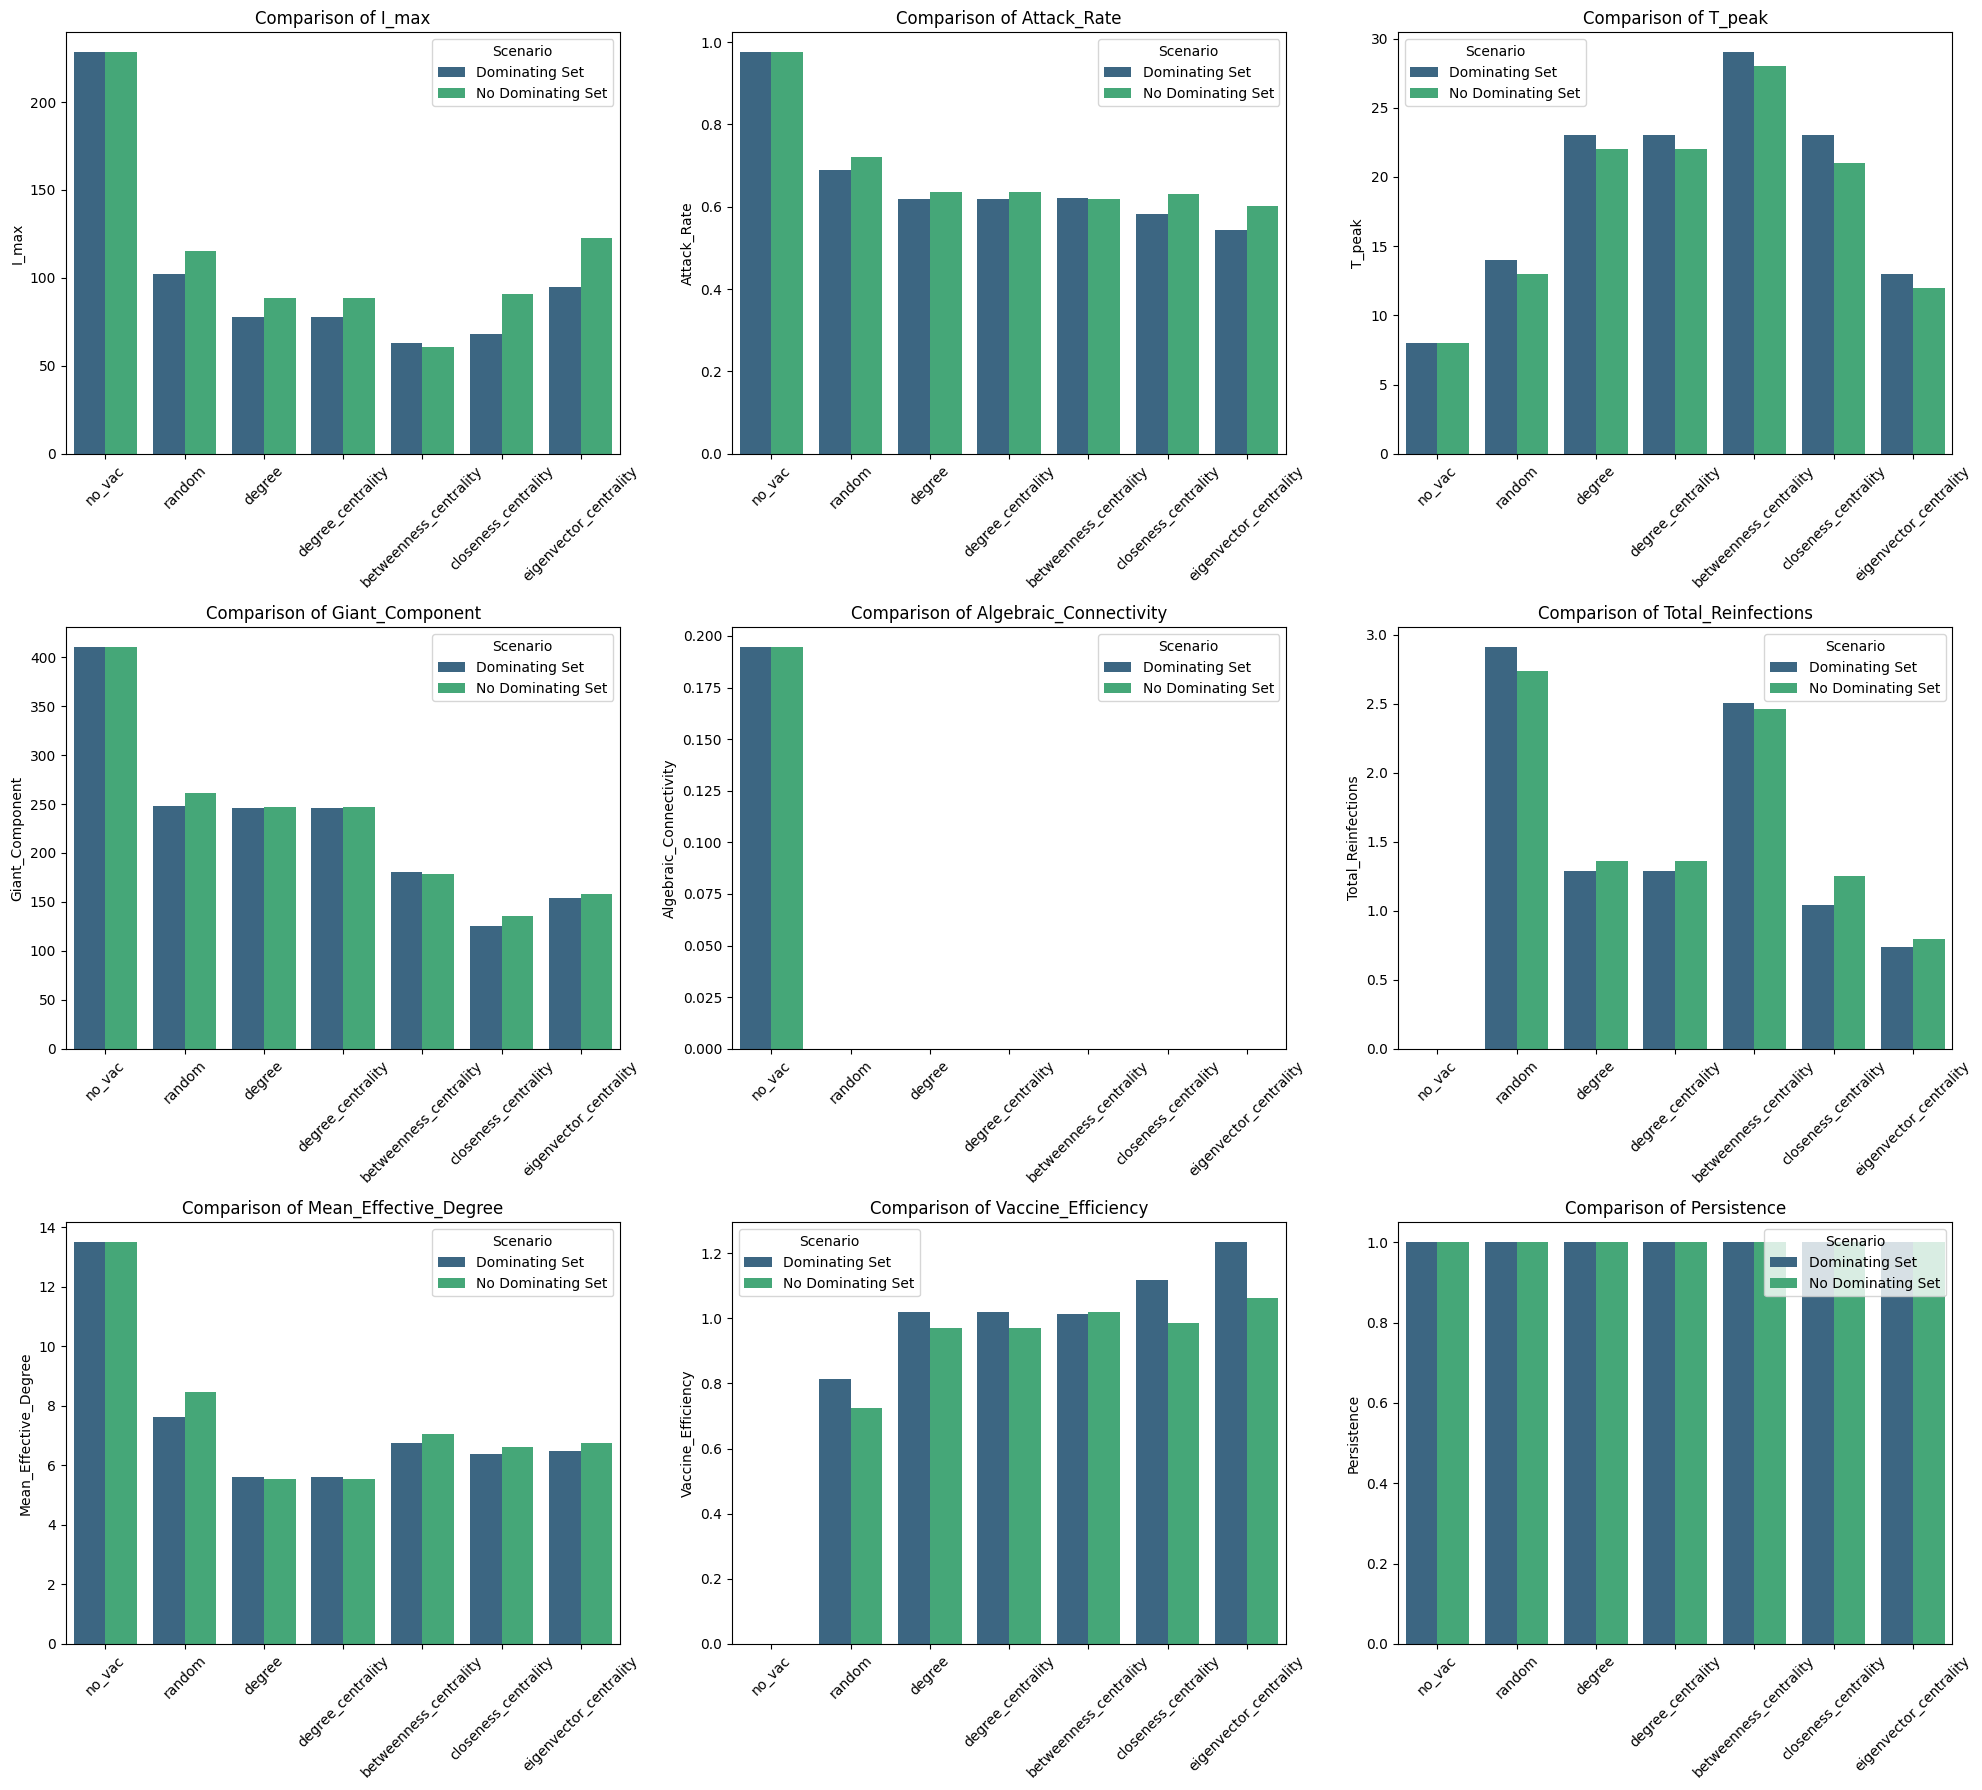

In [ ]:

plot_comparison_bar_charts(df_comparatif_ds, df_comparatif_nds)

## SI MODEL

In [ ]:
params = {
    'beta': 0.08,    # Taux de transmission standard (S -> I)

    # --- AJUSTEMENT SI CRUCIAL ---
    'gamma': 0.0,    # ZÉRO guérison pour les non-vaccinés (Pas de transition I -> R)
    'g': 0.0,        # ZÉRO guérison pour les vaccinés (Pas de transition I_v -> R_v)

    'epsilon': 0.0,  # Pas de réinfection (Inutile car R reste vide)
    'e': 0.0,        # Pas de réinfection chez le vacciné
    # -------------------------------

    # Paramètres d'efficacité du vaccin (S_v -> I_v)
    'b': 0.005,      # Le vaccin réduit la probabilité qu'un S_v devienne I_v
    'h': 0.001       # Un vacciné infecté (I_v) contamine presque personne (charge virale/contagiosité réduite)
}

### Using Dominating Set

In [ ]:

# 4. Exécution du pipeline
# liste_strategies = ["no_vac", "random", "degree", "degree_centrality", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_ds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Couverture vaccinale (15%)
    m=50,
    use_ds=True
)

# Affichage du tableau de bord d'analyse
print(df_comparatif[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  409.723333     0.999325    49.0            410.0   
random                  364.635188     0.889354    49.0            260.0   
degree                  339.020370     0.826879    49.0            247.0   
degree_centrality       339.020370     0.826879    49.0            247.0   
betweenness_centrality  339.296630     0.827553    49.0            179.0   
closeness_centrality    323.065445     0.787964    49.0            136.0   
eigenvector_centrality  284.038911     0.692778    49.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462                 0.0  
random                                0.000000                 0.0  
degree                                0.000000                 0.0  
degree_centrality                     0.000000                 0.0  
betweenness_centrality                0.000000

#Withouth Using the dominating Set

In [ ]:

# 4. Exécution du pipeline
# liste_strategies = ["no_vac", "random", "degree", "degree_centrality", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_nds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Couverture vaccinale (15%)
    m=50,
    use_ds=False
)

# Affichage du tableau de bord d'analyse
print(df_comparatif[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  409.723333     0.999325    49.0            410.0   
random                  364.635188     0.889354    49.0            260.0   
degree                  339.020370     0.826879    49.0            247.0   
degree_centrality       339.020370     0.826879    49.0            247.0   
betweenness_centrality  339.296630     0.827553    49.0            179.0   
closeness_centrality    323.065445     0.787964    49.0            136.0   
eigenvector_centrality  284.038911     0.692778    49.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462                 0.0  
random                                0.000000                 0.0  
degree                                0.000000                 0.0  
degree_centrality                     0.000000                 0.0  
betweenness_centrality                0.000000

### Plots

In [ ]:
import seaborn as sns

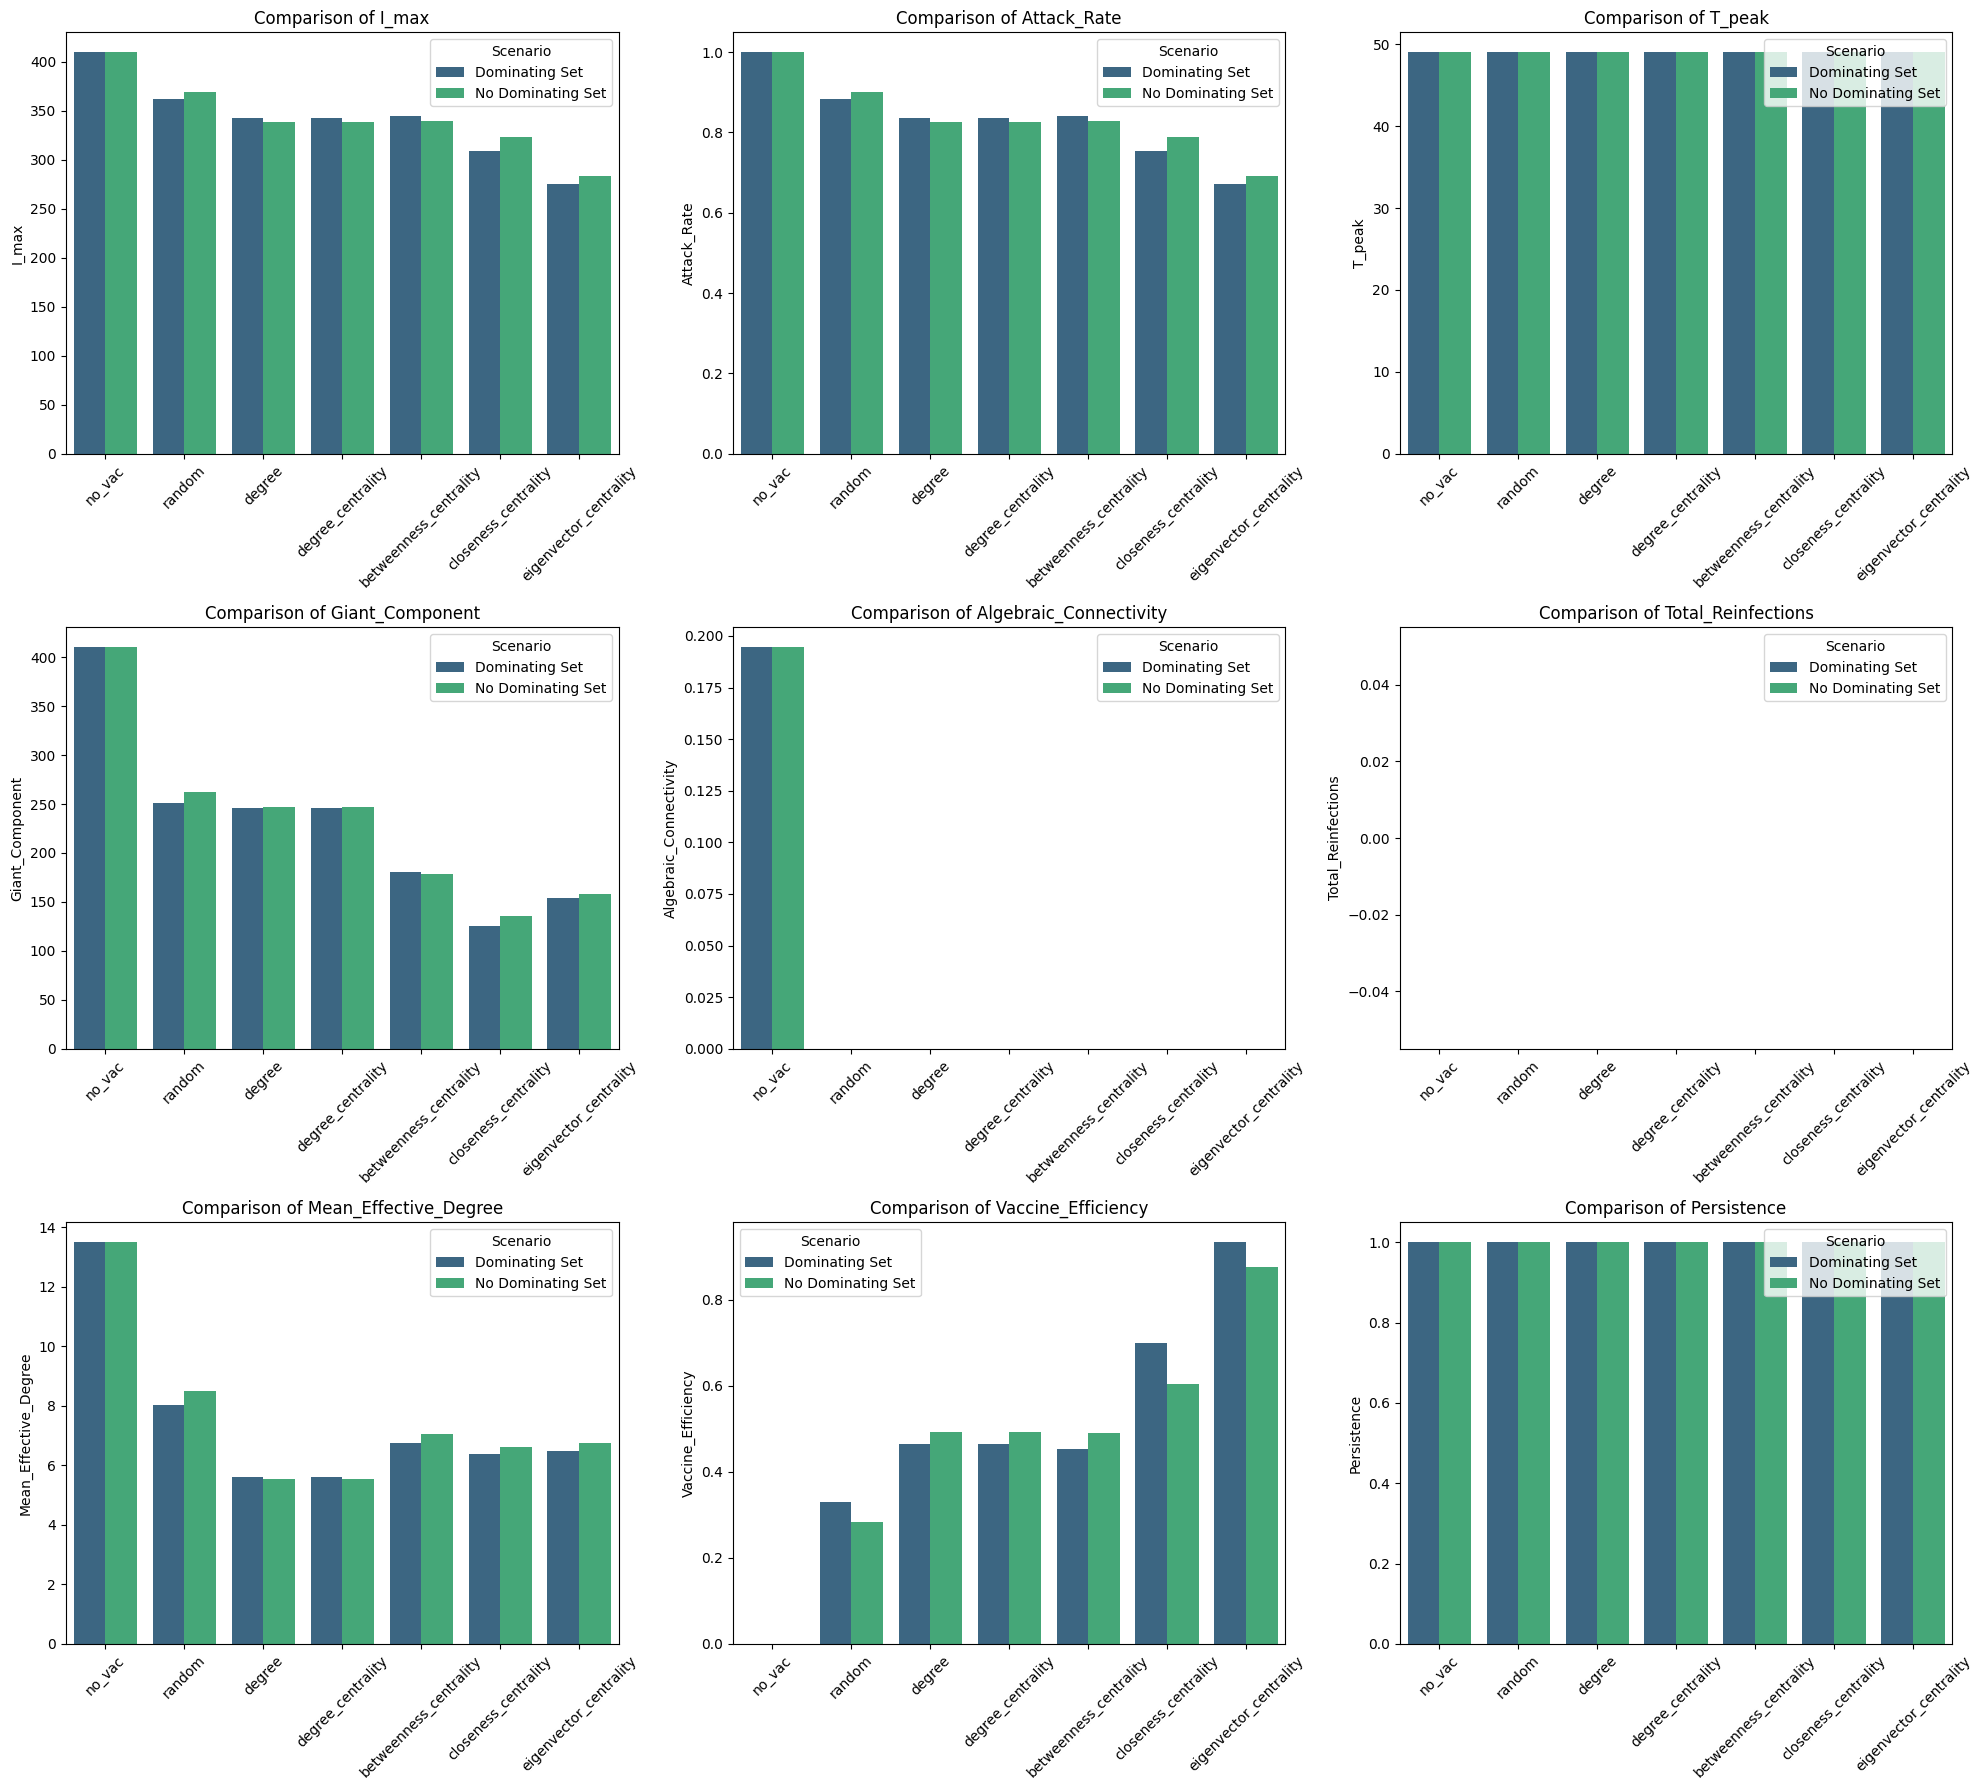

In [ ]:

# Call the new plotting function
plot_comparison_bar_charts(df_comparatif_ds, df_comparatif_nds)